In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from datetime import datetime

In [6]:
# load data
df = pd.read_excel('Inspection_Data.xlsx')

In [7]:
# Enhanced data preprocessing and feature engineering
def enhance_features(df):
    # 1. Time-based feature engineering
    # Convert inspection date to datetime
    df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'], origin='1899-12-30', unit='D')
    df['YEAR'] = df['INSPECTION DATE'].dt.year
    df['MONTH'] = df['INSPECTION DATE'].dt.month
    df['DAY'] = df['INSPECTION DATE'].dt.day
    df['WEEKDAY'] = df['INSPECTION DATE'].dt.dayofweek  # Day of the week (0=Monday, 6=Sunday)
    df['QUARTER'] = df['INSPECTION DATE'].dt.quarter  # Quarter of the year
    df['IS_WEEKEND'] = df['WEEKDAY'].isin([5, 6]).astype(int)  # Binary flag for weekends

    # 2. Geographic features
    # Map boroughs to their approximate population density (arbitrary values for demonstration)
    boro_density = {
        'MANHATTAN': 100,
        'BROOKLYN': 80,
        'QUEENS': 60,
        'BRONX': 70,
        'STATEN ISLAND': 40
    }
    df['BORO_DENSITY'] = df['BORO'].map(boro_density)

    # 3. Restaurant-specific features
    # Count the number of inspections for each restaurant
    df['INSPECTION_COUNT'] = df.groupby('CAMIS')['INSPECTION DATE'].transform('count')

    # 4. Cuisine category optimization
    # Map various cuisines into broader categories
    cuisine_mapping = {
        'Chinese': 'Asian',
        'Asian Fusion': 'Asian',
        'Japanese': 'Asian',
        'Korean': 'Asian',
        'Italian': 'Italian/Mediterranean',
        'Pizza': 'Italian/Mediterranean',
        'Mediterranean': 'Italian/Mediterranean',
        'Mexican': 'Latin American',
        'Tex-Mex': 'Latin American',
        'Latin American': 'Latin American',
        'American': 'American',
        'Hamburgers': 'American',
        'Soul Food': 'American',
        'Indian': 'Indian',
        'Bangladeshi': 'Indian',
        'Thai': 'Southeast Asian',
        'Vietnamese': 'Southeast Asian',
        'Southeast Asian': 'Southeast Asian',
        'French': 'European',
        'European': 'European',
        'Bistro': 'European',
        'Caribbean': 'Caribbean',
        'Jamaican': 'Caribbean',
        'Middle Eastern': 'Middle Eastern',
        'Turkish': 'Middle Eastern',
        'African': 'African',
        'Ethiopian': 'African',
        'Bakery': 'Bakery/Dessert',
        'Dessert': 'Bakery/Dessert',
        'Donuts': 'Bakery/Dessert',
        'Seafood': 'Seafood',
        'Cajun': 'Seafood',
        'Other': 'Other/Unclassified'
    }
    df['CUISINE CATEGORY'] = df['CUISINE DESCRIPTION'].replace(cuisine_mapping)

    # 5. Seasonal features
    # Map months to seasons (translated from Chinese)
    season_map = {
        1: 'Winter', 2: 'Winter', 3: 'Spring', 
        4: 'Spring', 5: 'Spring', 6: 'Summer',
        7: 'Summer', 8: 'Summer', 9: 'Fall',
        10: 'Fall', 11: 'Fall', 12: 'Winter'
    }
    df['SEASON'] = df['MONTH'].map(season_map)

    # 6. Historical performance features
    # Calculate the score from the previous inspection for each restaurant
    df['PREV_SCORE'] = df.groupby('CAMIS')['SCORE'].shift(1)
    df['SCORE_CHANGE'] = df['SCORE'] - df['PREV_SCORE']  # Change in score compared to the previous inspection
    df['AVG_HISTORICAL_SCORE'] = df.groupby('CAMIS')['SCORE'].transform('mean')  # Historical average score
    df['SCORE_STD'] = df.groupby('CAMIS')['SCORE'].transform('std')  # Historical standard deviation of scores

    # 7. Statistical features
    # Compare scores to borough and cuisine averages
    df['SCORE_VS_BORO_AVG'] = df['SCORE'] - df.groupby('BORO')['SCORE'].transform('mean')
    df['SCORE_VS_CUISINE_AVG'] = df['SCORE'] - df.groupby('CUISINE CATEGORY')['SCORE'].transform('mean')

    return df

In [8]:
# Apply feature engineering
df = enhance_features(df)

# Filter data for 2024
df_2024 = df[df['YEAR'] == 2024].copy()


In [9]:
# Aggregate metrics for each restaurant
restaurant_scores_2024 = df_2024.groupby('CAMIS').agg({
    'INSPECTION DATE': 'last',  # Most recent inspection date
    'SCORE': ['mean', 'std', 'count'],  # Average, standard deviation, and total inspections
    'BORO': 'first',
    'CUISINE CATEGORY': 'first',
    'SCORE_VS_BORO_AVG': 'mean',
    'SCORE_VS_CUISINE_AVG': 'mean',
    'INSPECTION_COUNT': 'max',  # Total inspections
    'BORO_DENSITY': 'first',
    'SCORE_CHANGE': ['mean', 'std'],  # Average and standard deviation of score changes
    'AVG_HISTORICAL_SCORE': 'first'
}).reset_index()

# Rename columns for clarity
restaurant_scores_2024.columns = ['CAMIS', 'INSPECTION DATE', 'AVG_SCORE', 'SCORE_STD', 
                                  'INSPECTION_COUNT', 'BORO', 'CUISINE_CATEGORY', 
                                  'BORO_SCORE_DIFF', 'CUISINE_SCORE_DIFF', 
                                  'TOTAL_INSPECTIONS', 'BORO_DENSITY',
                                  'AVG_SCORE_CHANGE', 'SCORE_CHANGE_STD', 'HISTORICAL_AVG']

# Fill missing values
restaurant_scores_2024['SCORE_STD'] = restaurant_scores_2024['SCORE_STD'].fillna(0)
restaurant_scores_2024['BORO_DENSITY'] = restaurant_scores_2024['BORO_DENSITY'].fillna(0)
restaurant_scores_2024['AVG_SCORE_CHANGE'] = restaurant_scores_2024['AVG_SCORE_CHANGE'].fillna(0)
restaurant_scores_2024['SCORE_CHANGE_STD'] = restaurant_scores_2024['SCORE_CHANGE_STD'].fillna(0)
restaurant_scores_2024['HISTORICAL_AVG'] = restaurant_scores_2024['HISTORICAL_AVG'].fillna(restaurant_scores_2024['AVG_SCORE'])

# Ensure numeric columns are properly formatted
numeric_columns = ['AVG_SCORE', 'SCORE_STD', 'INSPECTION_COUNT', 'BORO_SCORE_DIFF', 
                   'CUISINE_SCORE_DIFF', 'TOTAL_INSPECTIONS', 'BORO_DENSITY',
                   'AVG_SCORE_CHANGE', 'SCORE_CHANGE_STD', 'HISTORICAL_AVG']

for col in numeric_columns:
    restaurant_scores_2024[col] = pd.to_numeric(restaurant_scores_2024[col], errors='coerce')


/tmp/ipykernel_705/2207184979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=restaurant_scores_2024, x='BORO', y='AVG_SCORE', palette='viridis')
/tmp/ipykernel_705/2207184979.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=restaurant_scores_2024[restaurant_scores_2024['CUISINE_CATEGORY'].isin(top_cuisines.index)],
/tmp/ipykernel_705/2207184979.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=restaurant_scores_2024[restaurant_scores_2024['CUISINE_CATEGORY'].isin(top_cuisines.index)],


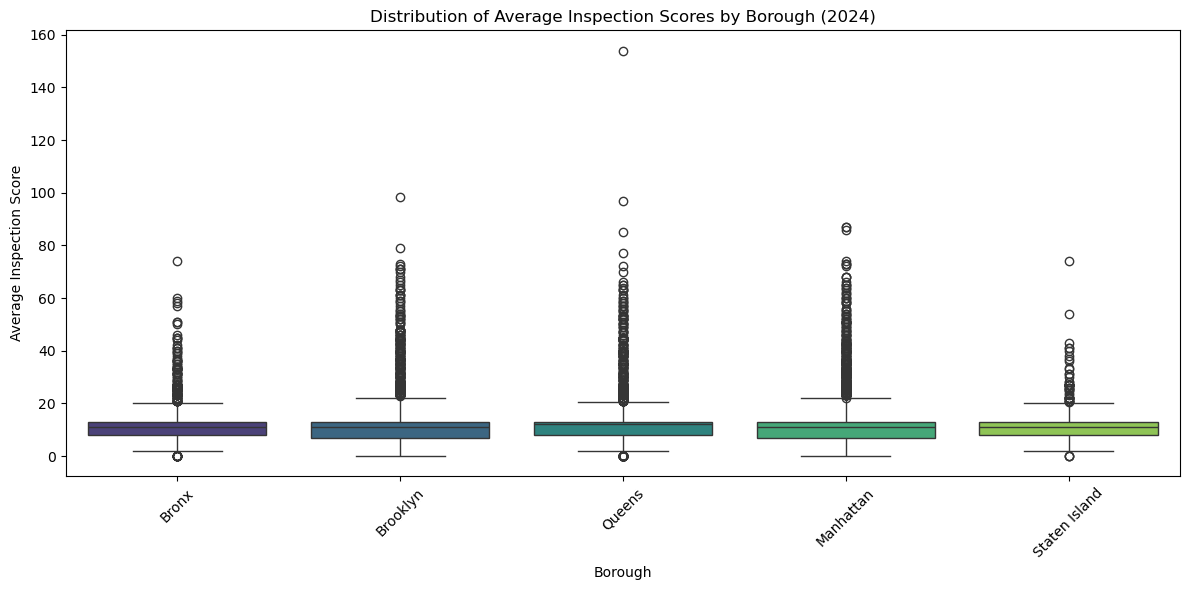

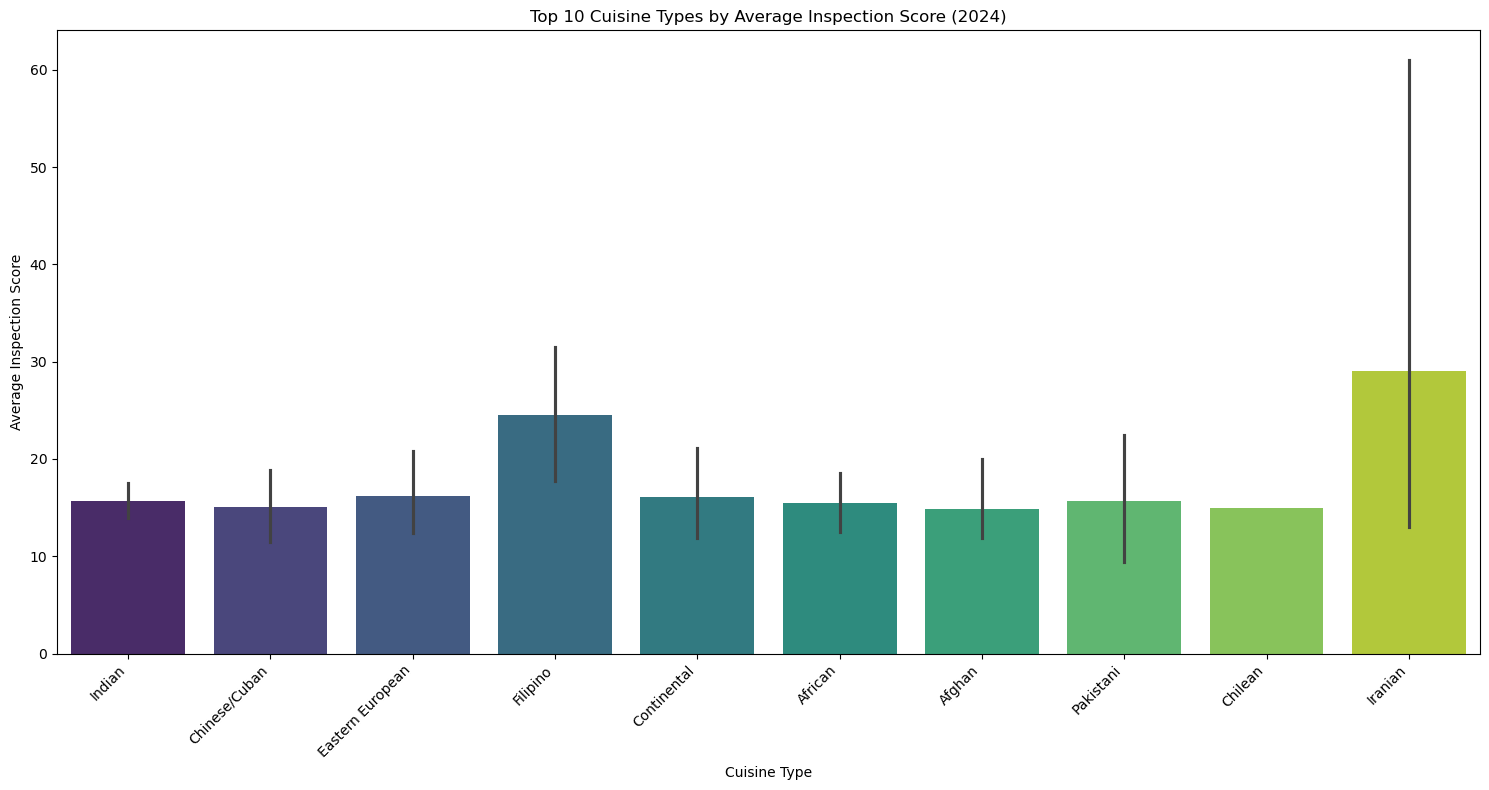

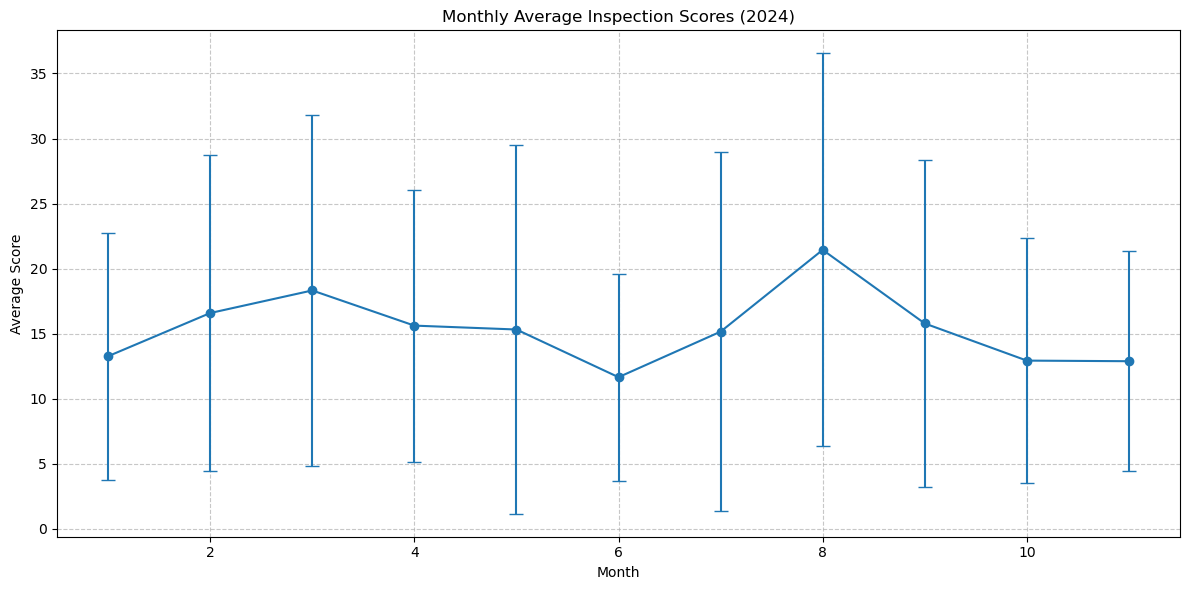

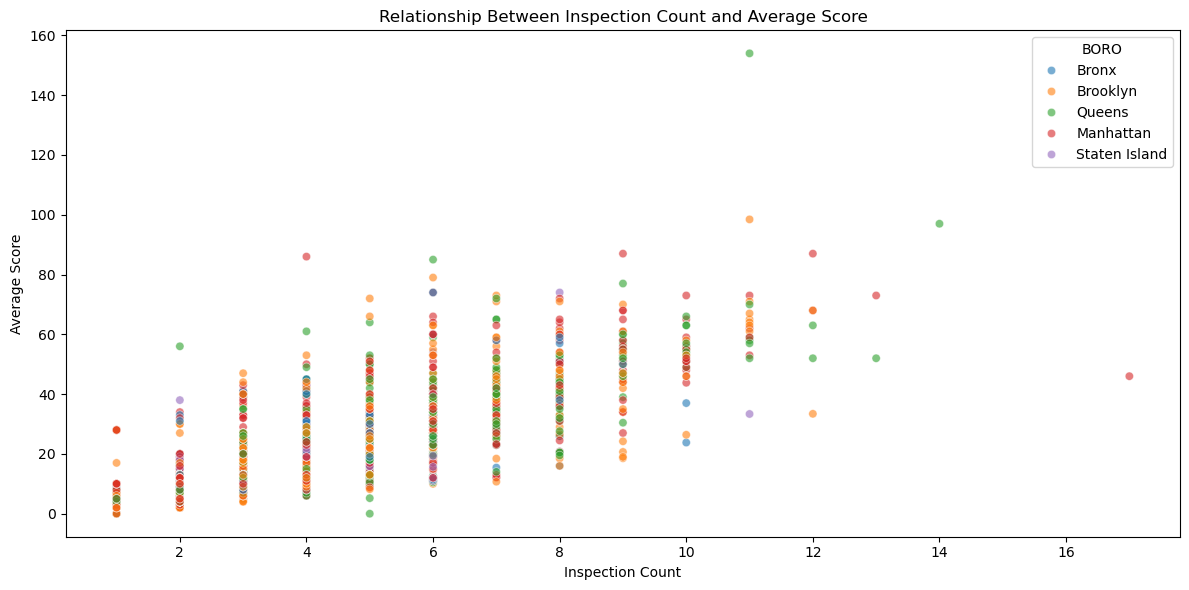

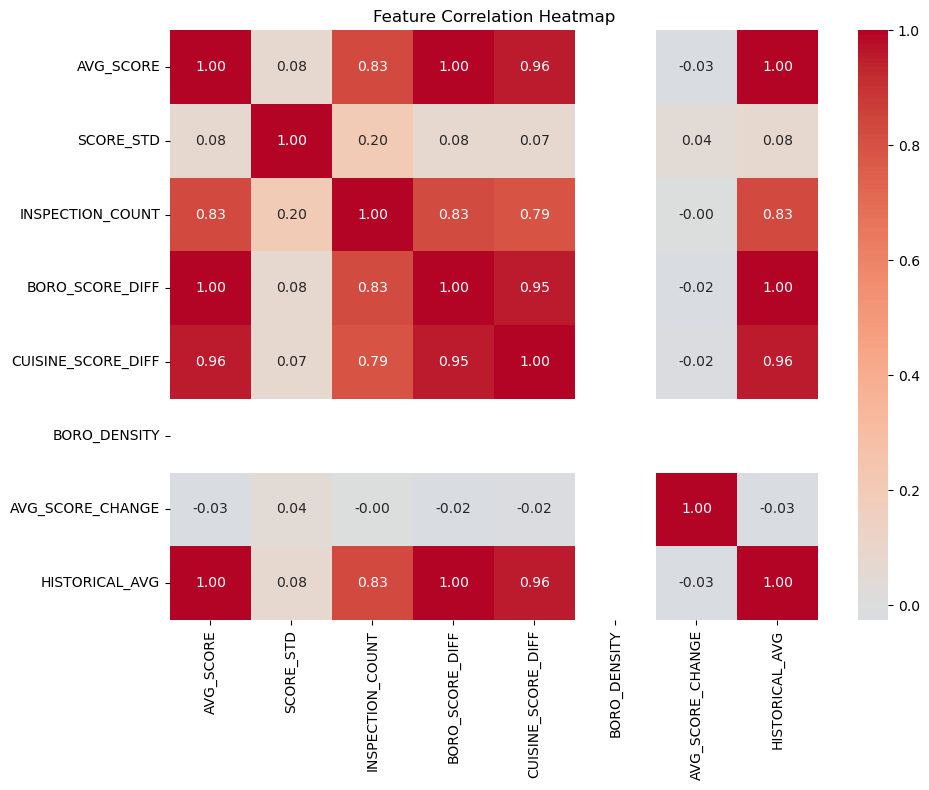

In [10]:
# Data analysis and visualization functions
def create_analysis_plots(df_2024, restaurant_scores_2024):
    # 1. Borough analysis
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=restaurant_scores_2024, x='BORO', y='AVG_SCORE', palette='viridis')
    plt.title('Distribution of Average Inspection Scores by Borough (2024)')
    plt.xlabel('Borough')
    plt.ylabel('Average Inspection Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. Cuisine analysis
    cuisine_analysis = restaurant_scores_2024.groupby('CUISINE_CATEGORY').agg({
        'AVG_SCORE': ['mean', 'std', 'count']
    }).round(2)
    cuisine_analysis = cuisine_analysis.sort_values(('AVG_SCORE', 'mean'), ascending=False)

    plt.figure(figsize=(15, 8))
    top_cuisines = cuisine_analysis.head(10)
    sns.barplot(data=restaurant_scores_2024[restaurant_scores_2024['CUISINE_CATEGORY'].isin(top_cuisines.index)],
                x='CUISINE_CATEGORY', y='AVG_SCORE', estimator='mean', ci=95, palette='viridis')
    plt.title('Top 10 Cuisine Types by Average Inspection Score (2024)')
    plt.xlabel('Cuisine Type')
    plt.ylabel('Average Inspection Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 3. Monthly trends
    monthly_scores = df_2024.groupby(['MONTH'])['SCORE'].agg(['mean', 'std', 'count']).reset_index()
    
    plt.figure(figsize=(12, 6))
    plt.errorbar(monthly_scores['MONTH'], 
                monthly_scores['mean'], 
                yerr=monthly_scores['std'],
                fmt='o-',
                capsize=5)
    plt.title('Monthly Average Inspection Scores (2024)')
    plt.xlabel('Month')
    plt.ylabel('Average Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 4. Relationship between inspection count and score
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=restaurant_scores_2024, 
                    x='INSPECTION_COUNT', 
                    y='AVG_SCORE', 
                    hue='BORO', 
                    alpha=0.6)
    plt.title('Relationship Between Inspection Count and Average Score')
    plt.xlabel('Inspection Count')
    plt.ylabel('Average Score')
    plt.tight_layout()
    plt.show()

    # 5. Correlation heatmap
    numeric_cols = ['AVG_SCORE', 'SCORE_STD', 'INSPECTION_COUNT', 
                   'BORO_SCORE_DIFF', 'CUISINE_SCORE_DIFF', 'BORO_DENSITY',
                   'AVG_SCORE_CHANGE', 'HISTORICAL_AVG']
    correlation_matrix = restaurant_scores_2024[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    return monthly_scores, cuisine_analysis

# Execute analysis and visualization
monthly_scores, cuisine_analysis = create_analysis_plots(df_2024, restaurant_scores_2024)

In [11]:
# Output statistical results
print("\nStatistical Summary by Borough (2024):")
print(restaurant_scores_2024.groupby('BORO')['AVG_SCORE'].describe().round(2))

print("\nMonthly Statistical Summary (2024):")
print(monthly_scores.round(2))

print("\nCuisine Analysis (2024):")
print(cuisine_analysis.round(2))

# Seasonal analysis
seasonal_analysis = df_2024.groupby('SEASON')['SCORE'].agg(['mean', 'std', 'count']).round(2)
print("\nSeasonal Analysis (2024):")
print(seasonal_analysis)

# Enhanced feature statistics
print("\nEnhanced Feature Statistical Summary:")
print(restaurant_scores_2024.describe().round(2))

# Save analysis results to an Excel file
output_file = './cleaning_data.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    restaurant_scores_2024.to_excel(writer, sheet_name='Detailed Analysis', index=False)
    monthly_scores.to_excel(writer, sheet_name='Monthly Analysis', index=False)
    cuisine_analysis.to_excel(writer, sheet_name='Cuisine Analysis')
    seasonal_analysis.to_excel(writer, sheet_name='Seasonal Analysis')

print(f"\nAnalysis results saved to: {output_file}")


Statistical Summary by Borough (2024):
                count   mean   std  min  25%   50%   75%     max
BORO                                                            
Bronx          1305.0  12.10  7.93  0.0  8.0  11.0  13.0   74.00
Brooklyn       3898.0  11.76  8.95  0.0  7.0  11.0  13.0   98.45
Manhattan      5049.0  11.76  8.48  0.0  7.0  11.0  13.0   87.00
Queens         3178.0  12.37  9.67  0.0  8.0  12.0  13.0  154.00
Staten Island   532.0  11.47  7.20  0.0  8.0  11.0  13.0   74.00

Monthly Statistical Summary (2024):
    MONTH   mean    std  count
0       1  13.25   9.51   2507
1       2  16.58  12.16   2931
2       3  18.31  13.47   4941
3       4  15.61  10.46   4024
4       5  15.31  14.17   3717
5       6  11.64   7.95   2629
6       7  15.14  13.78   2844
7       8  21.43  15.11   4745
8       9  15.77  12.54   3161
9      10  12.92   9.41   3762
10     11  12.87   8.48    620

Cuisine Analysis (2024):
                          AVG_SCORE             
                     

In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [13]:
def prepare_latest_inspections(df):
    """Prepare the latest inspection data."""
    df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'])
    latest_inspections = df.sort_values('INSPECTION DATE').groupby('CAMIS').last().reset_index()
    return latest_inspections

def check_data_quality(df):
    """Check data quality."""
    print("\nData Quality Report:")
    print("-" * 50)
    print(f"Data shape: {df.shape}")
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nData types:")
    print(df.dtypes)
    
    # Check basic statistics for numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("\nStatistics for numeric columns:")
    print(df[numeric_cols].describe())
    
    # Check for outliers
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
        print(f"\nNumber of outliers in {col}: {len(outliers)}")

def handle_outliers(df, numeric_features):
    """Handle outliers in numeric features."""
    df_clean = df.copy()
    for feature in numeric_features:
        q1 = df_clean[feature].quantile(0.25)
        q3 = df_clean[feature].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df_clean[feature] = df_clean[feature].clip(lower_bound, upper_bound)
    return df_clean

def preprocess_data(df):
    """Preprocess the data."""
    numeric_features = ['INSPECTION_COUNT', 'BORO_DENSITY', 'BORO_SCORE_DIFF',
                        'CUISINE_SCORE_DIFF', 'TOTAL_INSPECTIONS', 'AVG_SCORE_CHANGE',
                        'SCORE_CHANGE_STD']
    categorical_features = ['BORO', 'CUISINE_CATEGORY']
    
    # Check data quality
    check_data_quality(df)
    
    # Handle outliers
    df_cleaned = handle_outliers(df, numeric_features)
    
    # Separate features into numeric and categorical
    X_numeric = df_cleaned[numeric_features].copy()
    X_numeric = X_numeric.fillna(X_numeric.mean())  # Handle missing values in numeric columns
    
    X_categorical = df_cleaned[categorical_features].copy()
    
    # Handle rare categories in categorical features
    for cat_feature in categorical_features:
        value_counts = X_categorical[cat_feature].value_counts()
        rare_categories = value_counts[value_counts < 20].index  # Adjust threshold for rare categories
        X_categorical.loc[X_categorical[cat_feature].isin(rare_categories), cat_feature] = 'Other'
    
    X_categorical = X_categorical.fillna('Missing')  # Handle missing values in categorical columns
    
    # Define the target variable
    y = df_cleaned['AVG_SCORE']
    
    # Create a preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
        ])
    
    # Combine numeric and categorical features
    X = pd.concat([X_numeric, X_categorical], axis=1)
    
    return X, y, preprocessor

def build_regression_models(X, y, preprocessor):
    """Build and train regression models."""
    # Split the data into train and test sets using stratified sampling
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, q=5, labels=False)
    )
    
    # Define models and parameter grids for hyperparameter tuning
    models = {
        'Linear Regression': {
            'model': LinearRegression(),
            'params': {}
        },
        'Ridge Regression': {
            'model': Ridge(),
            'params': {
                'regressor__alpha': [0.1, 1.0, 10.0]
            }
        },
        'Lasso Regression': {
            'model': Lasso(),
            'params': {
                'regressor__alpha': [0.01, 0.1, 1.0]
            }
        },
        'Random Forest': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'regressor__n_estimators': [100, 200],
                'regressor__max_depth': [10, 20],
                'regressor__min_samples_split': [2, 5]
            }
        }
    }
    
    results = {}
    
    for name, model_info in models.items():
        print(f"\nTraining {name}...")
        
        # Create a complete pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('feature_selector', SelectKBest(f_regression, k='all')),
            ('pca', PCA(n_components=0.95)),  # Retain 95% of variance
            ('regressor', model_info['model'])
        ])
        
        # Perform hyperparameter tuning using GridSearchCV
        if model_info['params']:
            grid_search = GridSearchCV(
                pipeline,
                param_grid=model_info['params'],
                cv=5,
                scoring='r2',
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)
            best_pipeline = grid_search.best_estimator_
            print(f"Best parameters: {grid_search.best_params_}")
        else:
            best_pipeline = pipeline
            best_pipeline.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = best_pipeline.predict(X_train)
        y_test_pred = best_pipeline.predict(X_test)
        
        # Compute multiple evaluation metrics
        metrics = calculate_metrics(y_train, y_train_pred, y_test, y_test_pred)
        
        # Perform cross-validation
        cv = KFold(n_splits=10, shuffle=True, random_state=42)
        cv_scores = cross_val_score(best_pipeline, X, y, cv=cv, scoring='r2')
        
        results[name] = {
            'model': best_pipeline,
            'metrics': metrics,
            'cv_scores': cv_scores,
            'y_test': y_test,
            'y_test_pred': y_test_pred
        }
        
        print_results(name, metrics, cv_scores)
    
    return results, X_train, X_test, y_train, y_test

def calculate_metrics(y_train, y_train_pred, y_test, y_test_pred):
    """Calculate multiple evaluation metrics."""
    return {
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred)
    }


In [14]:
def print_results(name, metrics, cv_scores):
    """Print model results."""
    print(f"\n{name} Results:")
    print(f"Train R²: {metrics['train_r2']:.4f}")
    print(f"Test R²: {metrics['test_r2']:.4f}")
    print(f"Train RMSE: {metrics['train_rmse']:.4f}")
    print(f"Test RMSE: {metrics['test_rmse']:.4f}")
    print(f"Train MAE: {metrics['train_mae']:.4f}")
    print(f"Test MAE: {metrics['test_mae']:.4f}")
    print(f"Cross-validation R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std() * 2:.4f}")

def plot_regression_results(results):
    """Plot regression results."""
    for name, result in results.items():
        y_test = result['y_test']
        y_test_pred = result['y_test_pred']
        metrics = result['metrics']
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(f'{name} Model Results\nTest R² = {metrics["test_r2"]:.4f}, RMSE = {metrics["test_rmse"]:.4f}', 
                     fontsize=16)
        
        # Scatter plot of predictions vs actual values
        axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5)
        axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[0, 0].set_xlabel('Actual Values')
        axes[0, 0].set_ylabel('Predicted Values')
        axes[0, 0].set_title('Actual vs Predicted (Test Set)')
        
        # Residual plot
        residuals = y_test - y_test_pred
        axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5)
        axes[0, 1].axhline(y=0, color='r', linestyle='--')
        axes[0, 1].set_xlabel('Predicted Values')
        axes[0, 1].set_ylabel('Residuals')
        axes[0, 1].set_title('Residual Plot (Test Set)')
        
        # Residual distribution
        sns.histplot(residuals, kde=True, ax=axes[1, 0])
        axes[1, 0].set_xlabel('Residuals')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Residual Distribution (Test Set)')
        
        # Q-Q plot
        from scipy import stats
        stats.probplot(residuals, dist="norm", plot=axes[1, 1])
        axes[1, 1].set_title('Q-Q Plot (Residuals)')
        
        plt.tight_layout()
        plt.show()

def analyze_feature_importance(best_model, X, top_n=20):
    """Analyze feature importance."""
    # Get feature names
    feature_names = (best_model.named_steps['preprocessor']
                     .get_feature_names_out())
    
    if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
        # Feature importance for Random Forest
        importances = best_model.named_steps['regressor'].feature_importances_
    else:
        # Coefficients for linear models
        importances = np.abs(best_model.named_steps['regressor'].coef_)
    
    # Ensure length matches
    if len(feature_names) != len(importances):
        # Adjust feature numbers if PCA was applied
        n_components = best_model.named_steps['pca'].n_components_
        if len(importances) == n_components:
            feature_names = [f'PC{i + 1}' for i in range(n_components)]
    
    # Create a DataFrame for feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort and select top N features
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    if len(feature_importance) > top_n:
        feature_importance = feature_importance.head(top_n)
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(feature_importance)), feature_importance['Importance'])
    plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top {len(feature_importance)} Feature Importance')
    plt.tight_layout()
    plt.show()
    
    return feature_importance

def main():
    """Main function to run the pipeline."""
    # Load the data
    df = pd.read_excel('./cleaning_data.xlsx')
    
    # Data processing
    latest_inspections = prepare_latest_inspections(df)
    X, y, preprocessor = preprocess_data(latest_inspections)
    
    # Build and evaluate models
    results, X_train, X_test, y_train, y_test = build_regression_models(X, y, preprocessor)
    
    # Plot results
    plot_regression_results(results)
    
    # Select the best model
    best_model = None
    best_test_r2 = -np.inf
    for name, result in results.items():
        if result['metrics']['test_r2'] > best_test_r2:
            best_test_r2 = result['metrics']['test_r2']
            best_model = result['model']
    
    # Analyze feature importance
    feature_importance = analyze_feature_importance(best_model, X)
    print("\nFeature Importance Ranking:")
    print(feature_importance.to_string())
    
    return best_model, results



In [15]:
best_model, results = main()


Data Quality Report:
--------------------------------------------------
Data shape: (13962, 14)

Missing values:
CAMIS                 0
INSPECTION DATE       0
AVG_SCORE             0
SCORE_STD             0
INSPECTION_COUNT      0
BORO                  0
CUISINE_CATEGORY      0
BORO_SCORE_DIFF       0
CUISINE_SCORE_DIFF    0
TOTAL_INSPECTIONS     0
BORO_DENSITY          0
AVG_SCORE_CHANGE      0
SCORE_CHANGE_STD      0
HISTORICAL_AVG        0
dtype: int64

Data types:
CAMIS                          int64
INSPECTION DATE       datetime64[ns]
AVG_SCORE                    float64
SCORE_STD                    float64
INSPECTION_COUNT               int64
BORO                          object
CUISINE_CATEGORY              object
BORO_SCORE_DIFF              float64
CUISINE_SCORE_DIFF           float64
TOTAL_INSPECTIONS              int64
BORO_DENSITY                   int64
AVG_SCORE_CHANGE             float64
SCORE_CHANGE_STD             float64
HISTORICAL_AVG               float64
dtype:

In [12]:
def create_model_comparison_visualization(results):
    models = list(results.keys())
    metrics = {
        'Train R²': [results[model]['metrics']['train_r2'] for model in models],
        'Test R²': [results[model]['metrics']['test_r2'] for model in models],
        'Train RMSE': [results[model]['metrics']['train_rmse'] for model in models],
        'Test RMSE': [results[model]['metrics']['test_rmse'] for model in models],
        'CV R² (mean)': [results[model]['cv_scores'].mean() for model in models],
        'CV R² (std)': [results[model]['cv_scores'].std() for model in models]
    }

    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle('Model Performance Comparison', fontsize=16, y=1.02)

    # 1. R² Score Comparison
    x = np.arange(len(models))
    width = 0.35
    rects1 = axes[0,0].bar(x - width/2, metrics['Train R²'], width, label='Train', color='lightgreen')
    rects2 = axes[0,0].bar(x + width/2, metrics['Test R²'], width, label='Test', color='lightcoral')
    axes[0,0].set_ylabel('R² Score')
    axes[0,0].set_title('R² Score by Model')
    axes[0,0].set_xticks(x)
    axes[0,0].set_xticklabels(models, rotation=45)
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].bar_label(rects1, fmt='%.3f', padding=3)
    axes[0,0].bar_label(rects2, fmt='%.3f', padding=3)

    # 2. RMSE Comparison
    rects3 = axes[0,1].bar(x - width/2, metrics['Train RMSE'], width, label='Train', color='lightskyblue')
    rects4 = axes[0,1].bar(x + width/2, metrics['Test RMSE'], width, label='Test', color='sandybrown')
    axes[0,1].set_ylabel('RMSE')
    axes[0,1].set_title('RMSE by Model')
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(models, rotation=45)
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].bar_label(rects3, fmt='%.3f', padding=3)
    axes[0,1].bar_label(rects4, fmt='%.3f', padding=3)

    # 3. Cross-validation Performance
    cv_means = np.array(metrics['CV R² (mean)'])
    cv_stds = np.array(metrics['CV R² (std)'])
    x_pos = np.arange(len(models))
    rects5 = axes[1,0].bar(x_pos, cv_means, yerr=cv_stds, capsize=5, 
                          color='mediumpurple', alpha=0.7)
    axes[1,0].set_ylabel('Cross-validation R² Score')
    axes[1,0].set_title('Cross-validation Performance (mean ± std)')
    axes[1,0].set_xticks(x_pos)
    axes[1,0].set_xticklabels(models, rotation=45)
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].bar_label(rects5, fmt='%.3f', padding=3)

    # 4. Overfitting Analysis
    train_test_diff = [abs(tr - te) for tr, te in 
                      zip(metrics['Train R²'], metrics['Test R²'])]
    rects6 = axes[1,1].bar(x_pos, train_test_diff, color='khaki')
    axes[1,1].set_ylabel('|Train R² - Test R²|')
    axes[1,1].set_title('Overfitting Analysis')
    axes[1,1].set_xticks(x_pos)
    axes[1,1].set_xticklabels(models, rotation=45)
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].bar_label(rects6, fmt='%.3f', padding=3)

    plt.tight_layout()
    plt.show()

    print("\nDetailed Model Performance Metrics:")
    metrics_df = pd.DataFrame({
        'Train R²': metrics['Train R²'],
        'Test R²': metrics['Test R²'],
        'Train RMSE': metrics['Train RMSE'],
        'Test RMSE': metrics['Test RMSE'],
        'CV R² (mean)': metrics['CV R² (mean)'],
        'CV R² (std)': metrics['CV R² (std)']
    }, index=models)
    print(metrics_df.round(4))

create_model_comparison_visualization(results)

In [28]:
def analyze_rf_feature_importance(results):
    """Analyze and visualize Random Forest feature importance."""
    if 'Random Forest' not in results:
        print("Random Forest model not found in results.")
        return
    
    rf_model = results['Random Forest']['model']
    rf = rf_model.named_steps['regressor']
    
    feature_names = (rf_model.named_steps['preprocessor']
                    .get_feature_names_out())
    importances = rf.feature_importances_
    std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
    
    print(f"Length of feature_names: {len(feature_names)}")
    print(f"Length of importances: {len(importances)}")
    print(f"Length of std: {len(std)}")
    
    if len(feature_names) != len(importances) or len(feature_names) != len(std):
        print("Warning: Array lengths don't match. Adjusting arrays...")
        min_length = min(len(feature_names), len(importances), len(std))
        feature_names = feature_names[:min_length]
        importances = importances[:min_length]
        std = std[:min_length]
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances,
        'Std': std
    })
    
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
    
    print("\nRandom Forest Feature Importance Summary:")
    print("-" * 50)
    print(feature_importance_df.to_string())
    
    plt.figure(figsize=(12, 8))
    plt.bar(range(len(importances)), 
            feature_importance_df['Importance'],
            yerr=feature_importance_df['Std'],
            align='center')
    plt.xticks(range(len(importances)), 
               feature_importance_df['Feature'],
               rotation=45,
               ha='right')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()
    
    cumulative_importance = np.cumsum(feature_importance_df['Importance'])
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_importance) + 1), 
            cumulative_importance, 
            'bo-')
    plt.xlabel('Number of Features')
    plt.ylabel('Cumulative Importance')
    plt.title('Cumulative Feature Importance')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    print("\nFeature Importance Statistics:")
    print("-" * 50)
    print(f"Top 5 Most Important Features:")
    for idx, row in feature_importance_df.head().iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f} ± {row['Std']:.4f}")
    
    features_for_80 = len(cumulative_importance[cumulative_importance <= 0.8]) + 1
    print(f"\nNumber of features needed to explain 80% of variance: {features_for_80}")
    
    return feature_importance_df

feature_importance_df = analyze_rf_feature_importance(results)